In [1]:
import os
from style import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
TEST="receivers"

In [3]:
# res_path = f"../tests/{TEST}/out/npf_out_receivers_0%_loss_uniform.csv"
res_path = f"../tests/{TEST}/out/npf_out_smaller_receivers_uniform.csv"

In [4]:
data_df = pd.read_csv(res_path)

topo_name = str(data_df["TOPO_CONF_NAME"][0]).replace('"', "")
poisson = str(data_df["POISSON"][0]).replace('"', "")
is_poisson = poisson == "true"
poisson_str = "poisson" if is_poisson else "uniform"
print(f"is poisson?: {is_poisson}")

data_df["CURRENT_TEST"] = data_df["CURRENT_TEST"].str.replace('"', "")

data_df

is poisson?: False


,index,build,test_index,TEST_DIR_NAME,TOPO_CONF_NAME,FALLBACK_DELAY,CURRENT_TEST,NUM_CLIENTS,INTERVAL,POISSON,...,TEST_LENGTH,PER_CLIENT_LAT_RESULTS,WORKDIR,RUN_LOGS_DIR_BASELINE,RUN_LOGS_DIR_TCP,RUN_LOGS_DIR_FCQUIC_NO_FEC,RUN_LOGS_DIR_FCQUIC_FEC,CARGO_PATH,y_LATENCY,run_index
0,0,Local,0,receivers,smaller_receivers,100,FCQUIC_FEC,3,500,False,...,30,False,/home/corentin/fcquic_applications_master_thes...,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/.cargo/bin/cargo,6045.0,0
1,1,Local,0,receivers,smaller_receivers,100,FCQUIC_FEC,3,500,False,...,30,False,/home/corentin/fcquic_applications_master_thes...,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/.cargo/bin/cargo,6239.0,1
2,2,Local,0,receivers,smaller_receivers,100,FCQUIC_FEC,3,500,False,...,30,False,/home/corentin/fcquic_applications_master_thes...,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/.cargo/bin/cargo,6167.0,2
3,3,Local,0,receivers,smaller_receivers,100,FCQUIC_FEC,3,500,False,...,30,False,/home/corentin/fcquic_applications_master_thes...,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/.cargo/bin/cargo,6692.0,3
4,4,Local,0,receivers,smaller_receivers,100,FCQUIC_FEC,3,500,False,...,30,False,/home/corentin/fcquic_applications_master_thes...,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/.cargo/bin/cargo,7109.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1830,1830,Local,8,receivers,smaller_receivers,100,TCP,7,500,False,...,30,False,/home/corentin/fcquic_applications_master_thes...,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/.cargo/bin/cargo,7126.0,343
1831,1831,Local,8,receivers,smaller_receivers,100,TCP,7,500,False,...,30,False,/home/corentin/fcquic_applications_master_thes...,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/.cargo/bin/cargo,7272.0,344
1832,1832,Local,8,receivers,smaller_receivers,100,TCP,7,500,False,...,30,False,/home/corentin/fcquic_applications_master_thes...,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/.cargo/bin/cargo,7295.0,345
1833,1833,Local,8,receivers,smaller_receivers,100,TCP,7,500,False,...,30,False,/home/corentin/fcquic_applications_master_thes...,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/.cargo/bin/cargo,7305.0,346


array([3, 5, 7])

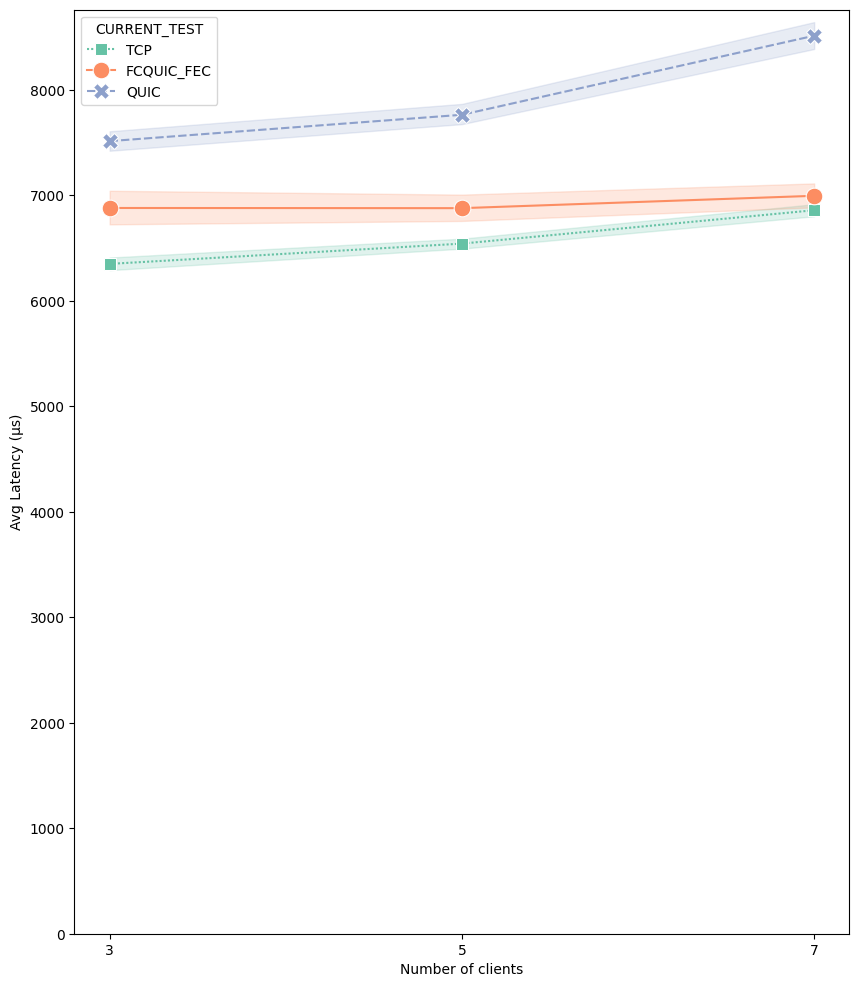

In [5]:
# latexify(nb_subplots_line=1, fig_height=8, fig_width=6)

num_clients = data_df["NUM_CLIENTS"].unique()
display(num_clients)

plt.figure(figsize=(10, 12))
sns.lineplot(
    x="NUM_CLIENTS", y="y_LATENCY", hue="CURRENT_TEST",
    data=data_df, palette='Set2', style="CURRENT_TEST", 
    markers=True, markersize=12, dashes=True, alpha=1,
    hue_order=["TCP","FCQUIC_FEC","QUIC"]
    )
plt.xlabel("Number of clients")
plt.ylabel("Avg Latency (µs)")
plt.ylim(bottom=0)
plt.xticks(num_clients)
plt.show()

<Figure size 1000x1200 with 0 Axes>

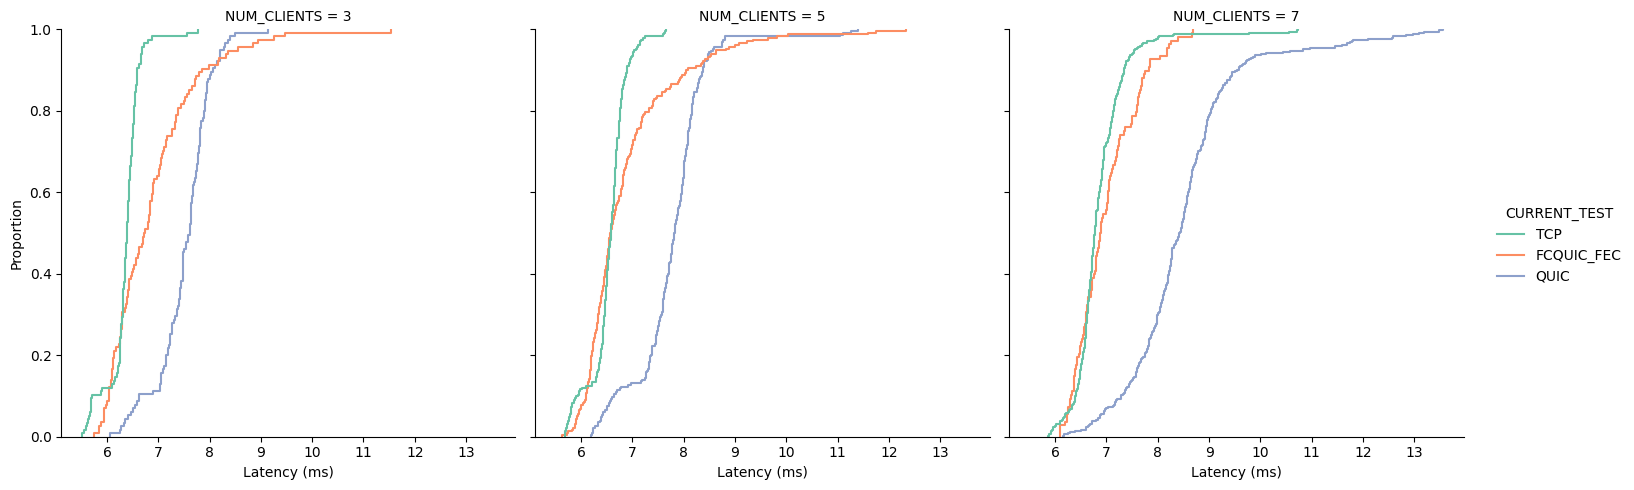

In [6]:
# latexify(nb_subplots_line=1, fig_height=8, fig_width=6)


plt.figure(figsize=(10, 12))
grid = sns.displot(
    kind="ecdf",
    x=data_df["y_LATENCY"]/1000, hue=data_df["CURRENT_TEST"],
    palette='Set2', col=data_df["NUM_CLIENTS"],
    hue_order=["TCP","FCQUIC_FEC","QUIC"]
    )

grid.set_axis_labels(x_var="Latency (ms)")
# plt.xlim(left=0)
plt.show()